In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/Lenovo/Downloads/diabetes_prediction.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (50000, 42)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


Physical_Activity_Level     500
Medication_Adherence       1000
dtype: int64


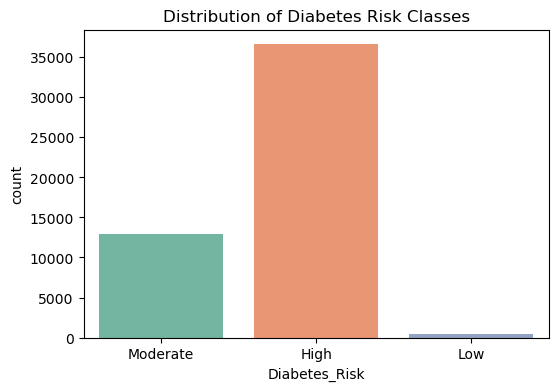

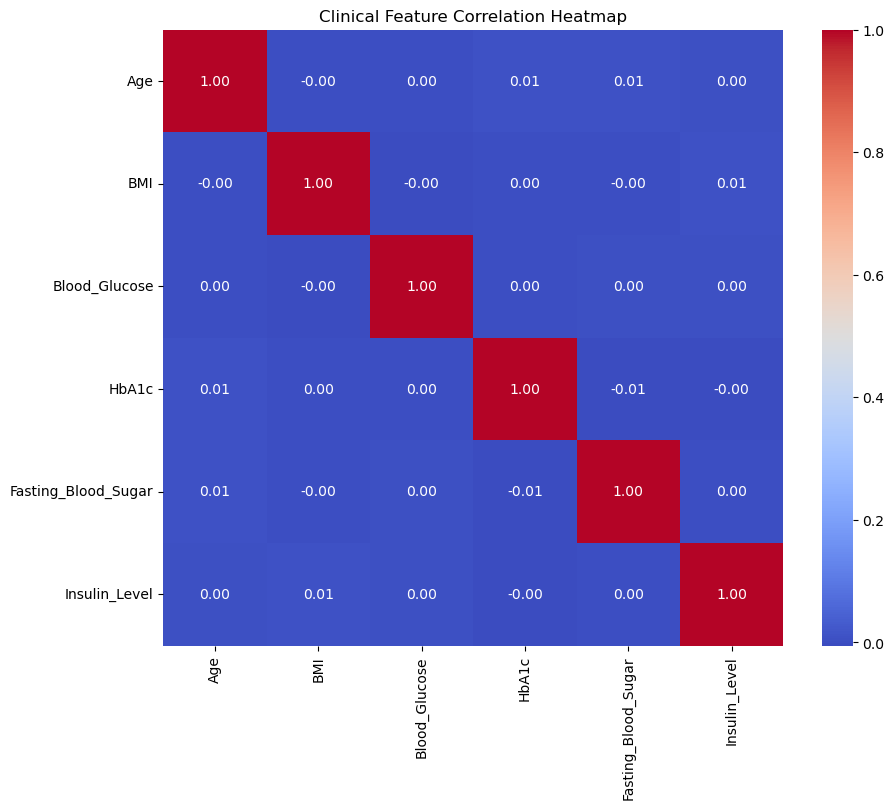

In [6]:
# Check missing values
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

# Fill missing values for numerical columns using median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Visualize Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Diabetes_Risk', data=df, hue='Diabetes_Risk', palette='Set2', legend=False)
plt.title('Distribution of Diabetes Risk Classes')
plt.show()

# Correlation Matrix of Key Clinical Features
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Age', 'BMI', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Clinical Feature Correlation Heatmap')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop identifier and direct target-leakage/administrative columns
drop_cols = ['Patient_ID', 'Diabetes_Risk', 'Diabetes_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['Diabetes_Risk']

# Encode categorical variables
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

# Train-Test Split (80-20 stratify to handle class imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy Score: 0.8986

Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.96      0.94      7319
         Low       0.92      0.12      0.21        94
    Moderate       0.85      0.74      0.79      2587

    accuracy                           0.90     10000
   macro avg       0.89      0.61      0.65     10000
weighted avg       0.90      0.90      0.89     10000



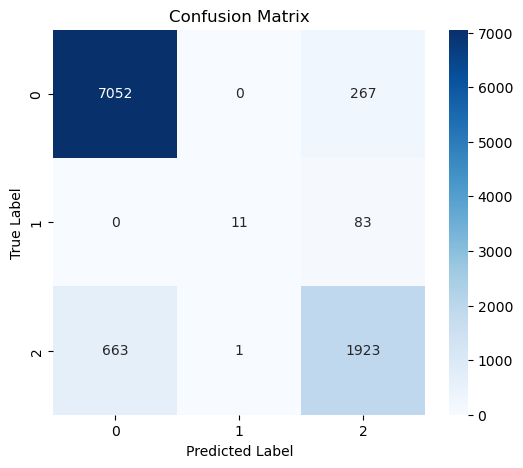

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=150, 
    max_depth=15, 
    class_weight='balanced', 
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Re-run predictions and evaluation
y_pred = rf_model.predict(X_test_scaled)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

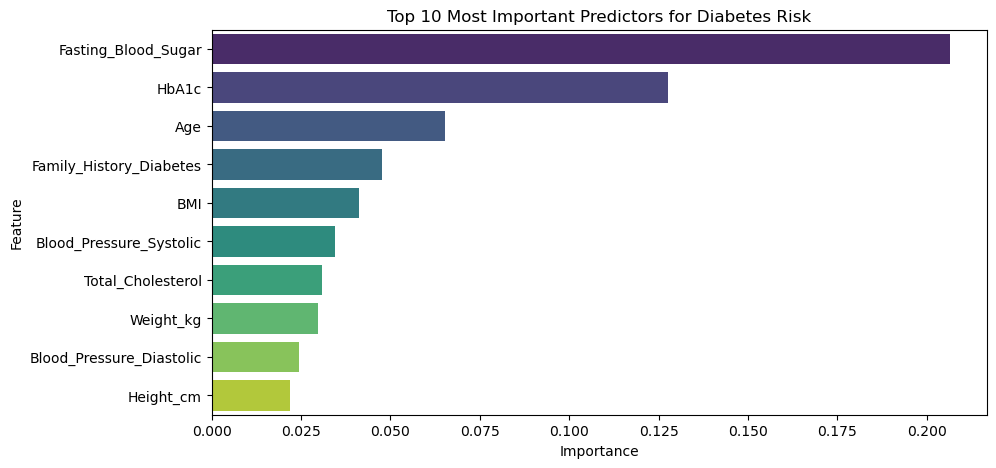

In [12]:
# Top 10 Feature Importances Plot (Updated if needed)
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Most Important Predictors for Diabetes Risk')
plt.show()